In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
data = np.load(r"D:\PENTING KUYLAH\output\3\data.npy")
earth_pos=np.load(r"D:\PENTING KUYLAH\output\3\earth_pos.npy")
moon_pos=np.load(r"D:\PENTING KUYLAH\output\3\moon_pos.npy")
print(data.shape)
print(earth_pos.shape)
print(moon_pos.shape)
data=(data*149_597_870.7)/1000
earth_pos=(earth_pos*149_597_870.7)/1000
moon_pos=(moon_pos*149_597_870.7)/1000


(87661, 2000, 3)
(87661, 3)
(87661, 3)


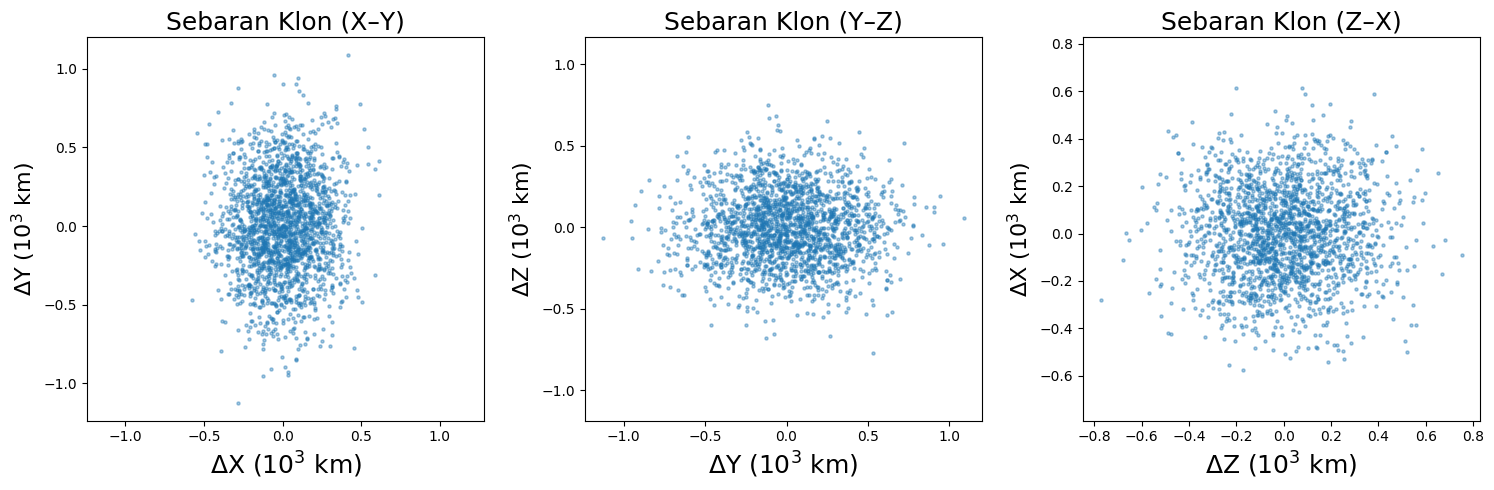

In [6]:
t0_data_pos=np.zeros((data.shape[1], 3))
for i in range (data.shape[1]):
    t0_data_pos[i,0]=data[0,i,0]
    t0_data_pos[i,1]=data[0,i,1]
    t0_data_pos[i,2]=data[0,i,2]

pairs = [
    (0, 1, r"ΔX ($10^{3}$ km)", r"ΔY ($10^{3}$ km)", "Sebaran Klon (X–Y)"),
    (1, 2, r"ΔY ($10^{3}$ km)", r"ΔZ ($10^{3}$ km)", "Sebaran Klon (Y–Z)"),
    (2, 0, r"ΔZ ($10^{3}$ km)", r"ΔX ($10^{3}$ km)", "Sebaran Klon (Z–X)")
]

plt.figure(figsize=(15,5))

for i, (ix, iy, xlabel, ylabel, title) in enumerate(pairs, start=1):
    x = t0_data_pos[:, ix]
    y = t0_data_pos[:, iy]

    x0 = x.mean()
    y0 = y.mean()

    plt.subplot(1, 3, i)
    plt.scatter(
        x - x0,
        y - y0,
        s=5,
        alpha=0.4
    )
    plt.xlabel(xlabel,fontsize=18)
    plt.ylabel(ylabel,fontsize=16)
    plt.title(title,fontsize=18)
    plt.axis("equal")

plt.tight_layout()
plt.savefig('persebaran_klon_t0_3.png', dpi=300, bbox_inches='tight')
plt.show()



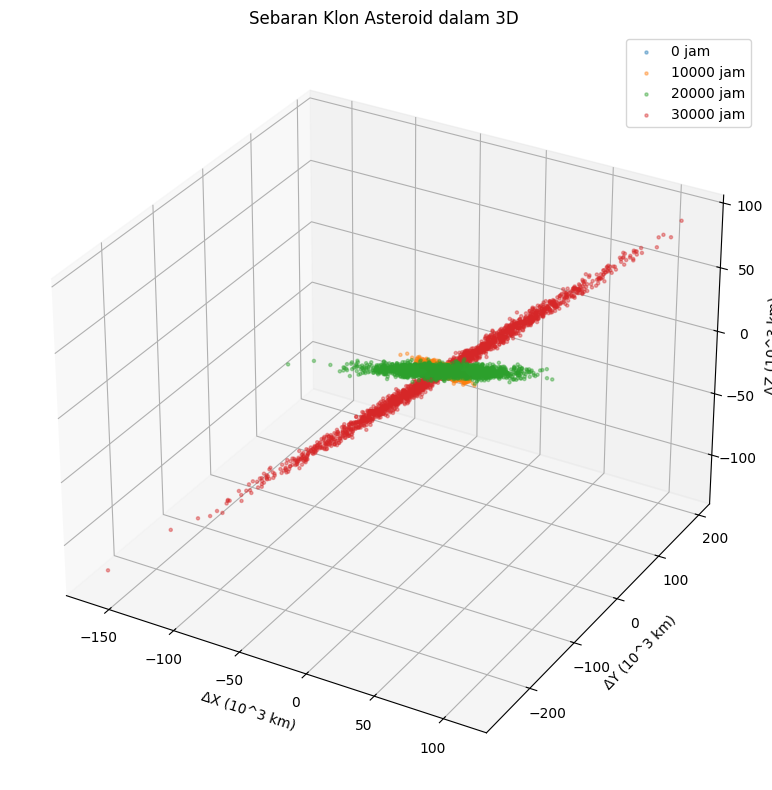

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# pilih timestep
timesteps = [0, 10000, 20000, 30000]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for t_idx in timesteps:

    pos = data[t_idx]

    x = pos[:, 0]
    y = pos[:, 1]
    z = pos[:, 2]

    # mean-center
    x = x - x.mean()
    y = y - y.mean()
    z = z - z.mean()

    ax.scatter(x, y, z, s=5, alpha=0.4, label=f"{t_idx} jam")

ax.set_xlabel("ΔX (10^3 km)")
ax.set_ylabel("ΔY (10^3 km)")
ax.set_zlabel("ΔZ (10^3 km)")

ax.set_title("Sebaran Klon Asteroid dalam 3D")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

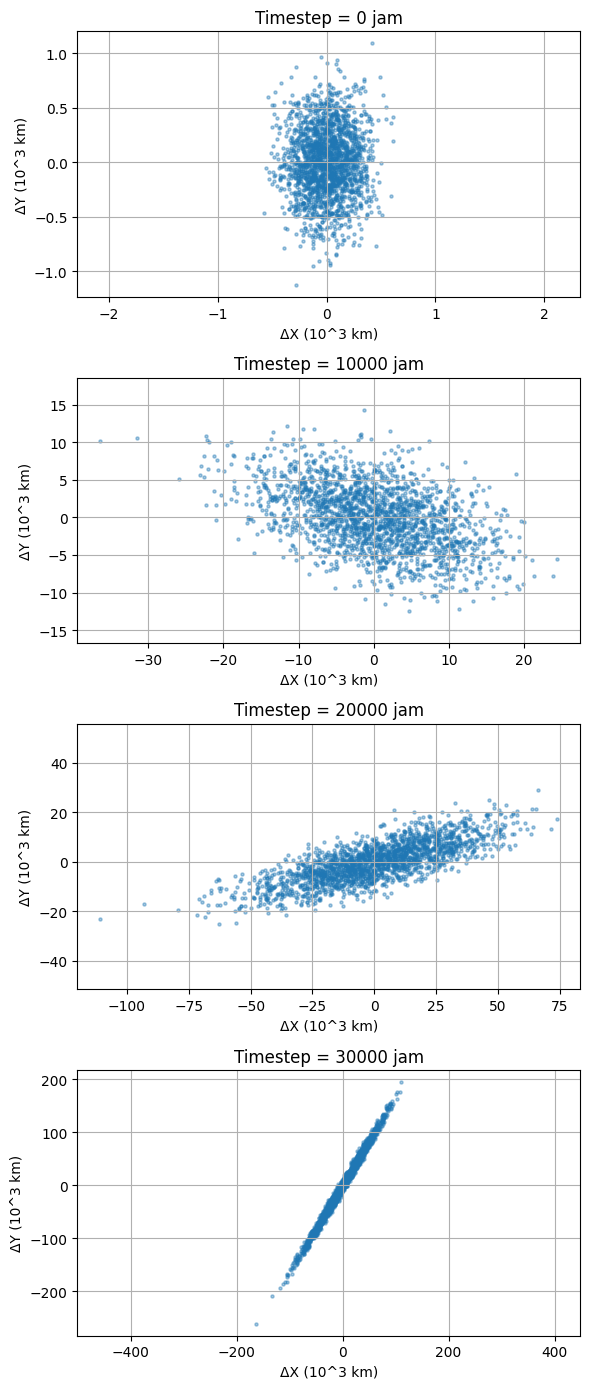

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# pilih 4 timestep
timesteps = [0, 10000, 20000, 30000]

# 4 baris, 1 kolom (vertikal)
fig, axes = plt.subplots(4, 1, figsize=(6, 14))

for i, t_idx in enumerate(timesteps):

    pos = data[t_idx]

    x = pos[:, 0]
    y = pos[:, 1]

    # mean-center
    x = x - x.mean()
    y = y - y.mean()

    axes[i].scatter(
        x,
        y,
        s=5,
        alpha=0.4
    )

    axes[i].set_title(f"Timestep = {t_idx} jam")
    axes[i].set_xlabel("ΔX (10^3 km)")
    axes[i].set_ylabel("ΔY (10^3 km)")
    axes[i].axis("equal")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

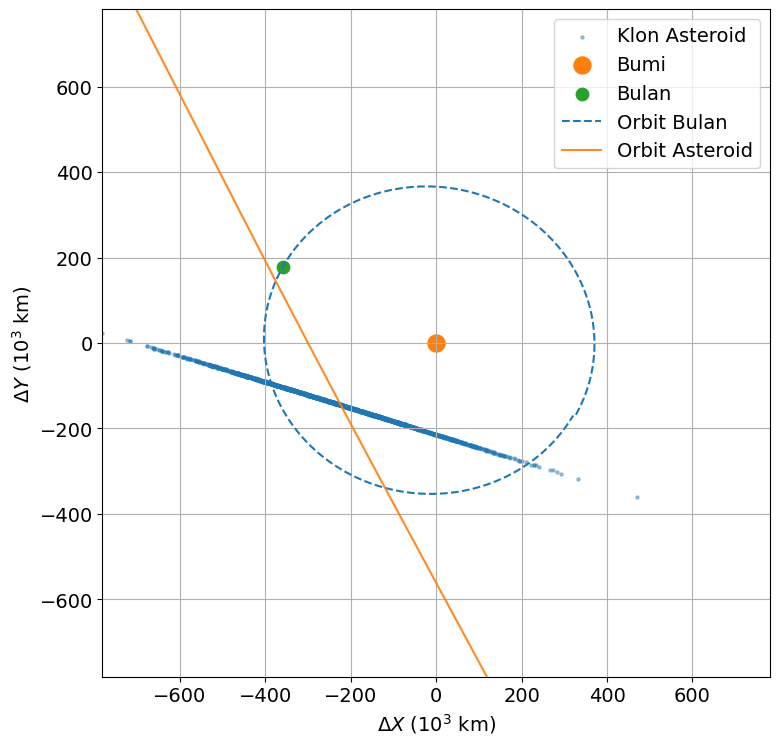

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
f_size=14
# samakan ukuran font
plt.rcParams.update({
    "font.size": f_size,
    "axes.titlesize": f_size,
    "axes.labelsize": f_size,
    "xtick.labelsize": f_size,
    "ytick.labelsize": f_size,
    "legend.fontsize": f_size
})

# waktu awal dalam UTC
t0 = datetime(2025, 1, 20, 0, 0, tzinfo=timezone.utc)

t_idx = 69440  # dalam jam

# hitung waktu aktual UTC
current_time = t0 + timedelta(hours=int(t_idx))
waktu_str = current_time.strftime("%d %B %Y, %H:%M UTC")

clone_pos = data[t_idx]
earth = earth_pos[t_idx]
moon = moon_pos[t_idx]

# Relatif terhadap Earth
rel_clone = clone_pos - earth
rel_moon = moon - earth

x = rel_clone[:, 0]
y = rel_clone[:, 1]

moon_x = rel_moon[0]
moon_y = rel_moon[1]

plt.figure(figsize=(8,8))

# =========================
# KLON ASTEROID (snapshot)
# =========================
plt.scatter(x, y, s=5, alpha=0.4, label="Klon Asteroid")

# Earth di pusat
plt.scatter(0, 0, s=150, marker='o', label="Bumi")

# Moon (posisi saat t_idx)
plt.scatter(moon_x, moon_y, s=80, marker='o', label="Bulan")

# =========================
# ORBIT BULAN (1 periode real)
# =========================
moon_period = int(27.321661 * 24)   # ~655 jam
half_period = moon_period // 2

start = max(0, t_idx - half_period)
end   = min(len(moon_pos), t_idx + half_period)

moon_segment = moon_pos[start:end] - earth_pos[start:end]

orbit_x = moon_segment[:, 0]
orbit_y = moon_segment[:, 1]

plt.plot(
    orbit_x, orbit_y,
    linewidth=1.5,
    linestyle='--',
    label="Orbit Bulan"
)

# =========================
# ORBIT 1 KLON (representatif)
# =========================
clone_index = 0

clone_orbit_rel = data[:, clone_index, :] - earth_pos

orbit_ast_x = clone_orbit_rel[:, 0]
orbit_ast_y = clone_orbit_rel[:, 1]

plt.plot(
    orbit_ast_x, orbit_ast_y,
    linewidth=1.5,
    alpha=0.9,
    label="Orbit Asteroid"
)

# =========================
# Pusatkan Earth di tengah
# =========================
max_range = max(
    np.max(np.abs(x)),
    np.max(np.abs(y)),
    np.max(np.abs(orbit_x)),
    np.max(np.abs(orbit_y))
)

plt.xlim(-max_range, max_range)
plt.ylim(-max_range, max_range)

plt.xlabel(r"$\Delta X$ ($10^{3}$ km)")
plt.ylabel(r"$\Delta Y$ ($10^{3}$ km)")


plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig("posisi_close_approach_3.png", dpi=600, bbox_inches="tight")

plt.show()

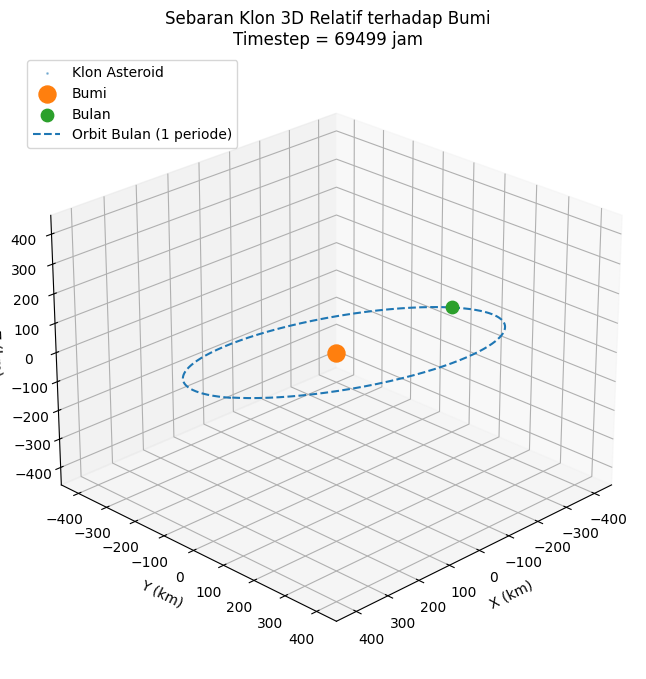

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Parameter
# =========================
timesteps = range(69400, 69500, 1)
moon_period = int(27.321661 * 24)
half_period = moon_period // 2

# =========================
# Radius orbit Bulan
# =========================
moon_distance = np.linalg.norm(moon_pos - earth_pos, axis=1)
orbit_radius = moon_distance.mean()
limit = orbit_radius * 1.2

# =========================
# Setup Figure 3D
# =========================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter objects (kosong dulu)
scat_clone = ax.scatter([], [], [], s=1, alpha=0.4, label="Klon Asteroid")
scat_earth = ax.scatter([0], [0], [0], s=150, marker='o', label="Bumi")
scat_moon  = ax.scatter([], [], [], s=80, marker='o', label="Bulan")

orbit_moon_line, = ax.plot([], [], [], linestyle='--',
                           linewidth=1.5,
                           label="Orbit Bulan (1 periode)")

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.legend(loc="upper left")


# =========================
# Update Function
# =========================
def update(t_idx):

    ax.view_init(elev=25, azim=45)  # sudut kamera tetap

    clone_pos = data[t_idx]
    earth = earth_pos[t_idx]
    moon = moon_pos[t_idx]

    # Relatif terhadap Earth
    rel_clone = clone_pos - earth
    rel_moon = moon - earth

    x = rel_clone[:, 0]
    y = rel_clone[:, 1]
    z = rel_clone[:, 2]

    moon_x = rel_moon[0]
    moon_y = rel_moon[1]
    moon_z = rel_moon[2]

    # Update klon
    scat_clone._offsets3d = (x, y, z)

    # Update bulan
    scat_moon._offsets3d = ([moon_x], [moon_y], [moon_z])

    # Orbit Bulan (1 periode)
    start = max(0, t_idx - half_period)
    end   = min(len(moon_pos), t_idx + half_period)

    moon_segment = moon_pos[start:end] - earth_pos[start:end]

    orbit_moon_line.set_data(
        moon_segment[:, 0],
        moon_segment[:, 1]
    )
    orbit_moon_line.set_3d_properties(moon_segment[:, 2])

    ax.set_title(f"Sebaran Klon 3D Relatif terhadap Bumi\nTimestep = {t_idx} jam")

    return scat_clone, scat_moon, orbit_moon_line


# =========================
# Animasi
# =========================
ani = FuncAnimation(fig,
                    update,
                    frames=timesteps,
                    interval=100)

ani.save("orbit_3d.gif",
         writer=PillowWriter(fps=5))

plt.show()

Jumlah klon yang nabrak: 7
Indeks klon yang nabrak: [   6  106 1655 1850 1910 1952 1997]


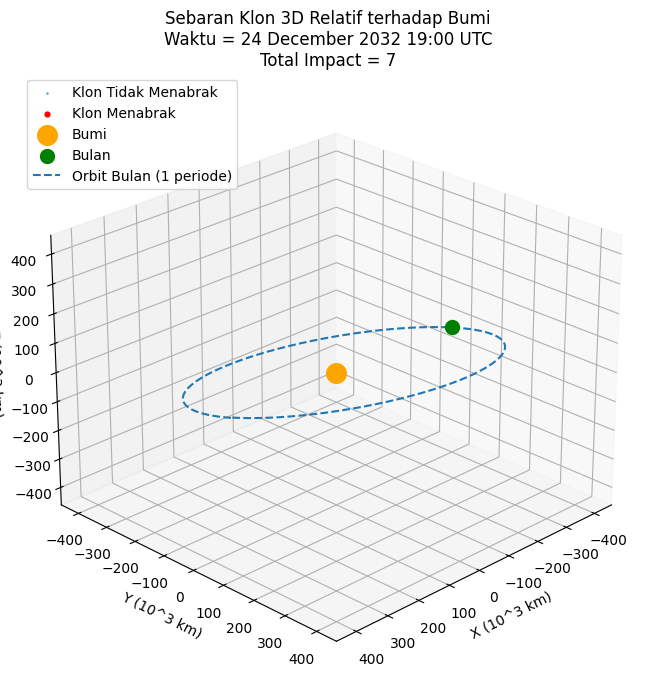

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime, timedelta
dist_min= np.load (r"D:\PENTING KUYLAH\output\3\dist.npy")
# =========================
# HITUNG KLON YANG TABRAKAN
# =========================
earth_dist = np.zeros(dist_min.shape[1])

for i in range(dist_min.shape[1]):
    earth_dist[i] = np.min(dist_min[:, i, 1])

AU_TO_KM = 149_597_870.7
earth_dist_km = earth_dist * AU_TO_KM

R_earth = 6371  # km

impact_indices = np.where(earth_dist_km < R_earth)[0]

print("Jumlah klon yang nabrak:", len(impact_indices))
print("Indeks klon yang nabrak:", impact_indices)


# =========================
# PARAMETER WAKTU
# =========================
t0 = datetime(2025, 1, 20, 0, 0, 0)  # UTC

timesteps = range(69400, 69500, 1)


# =========================
# PARAMETER ORBIT BULAN
# =========================
moon_period = int(27.321661 * 24)
half_period = moon_period // 2

moon_distance = np.linalg.norm(moon_pos - earth_pos, axis=1)
orbit_radius = moon_distance.mean()
limit = orbit_radius * 1.2


# =========================
# SETUP FIGURE 3D
# =========================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Klon tidak menabrak (biru)
scat_clone_normal = ax.scatter([], [], [], 
                               s=1, alpha=0.5,

                               label="Klon Tidak Menabrak")

# Klon menabrak (merah)
scat_clone_impact = ax.scatter([], [], [], 
                               s=12, alpha=1.0,
                               color='red',
                               label="Klon Menabrak")

# Bumi (oranye)
scat_earth = ax.scatter([0], [0], [0],
                        s=200,
                        color='orange',
                        marker='o',
                        label="Bumi")

# Bulan (hijau)
scat_moon  = ax.scatter([], [], [],
                        s=100,
                        color='green',
                        marker='o',
                        label="Bulan")

orbit_moon_line, = ax.plot([], [], [],
                           linestyle='--',
                           linewidth=1.5,
                           
                           label="Orbit Bulan (1 periode)")

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

ax.set_xlabel("X (10^3 km)")
ax.set_ylabel("Y (10^3 km)")
ax.set_zlabel("Z (10^3 km)")

ax.legend(loc="upper left")


# =========================
# UPDATE FUNCTION
# =========================
def update(t_idx):

    ax.view_init(elev=25, azim=45)

    clone_pos = data[t_idx]
    earth = earth_pos[t_idx]
    moon = moon_pos[t_idx]

    rel_clone = clone_pos - earth
    rel_moon = moon - earth

    # Pisahkan klon
    all_indices = np.arange(rel_clone.shape[0])
    normal_indices = np.setdiff1d(all_indices, impact_indices)

    clone_normal = rel_clone[normal_indices]
    clone_impact = rel_clone[impact_indices]

    # Update klon tidak menabrak
    if len(clone_normal) > 0:
        scat_clone_normal._offsets3d = (
            clone_normal[:, 0],
            clone_normal[:, 1],
            clone_normal[:, 2]
        )

    # Update klon menabrak
    if len(clone_impact) > 0:
        scat_clone_impact._offsets3d = (
            clone_impact[:, 0],
            clone_impact[:, 1],
            clone_impact[:, 2]
        )

    # Update bulan
    scat_moon._offsets3d = (
        [rel_moon[0]],
        [rel_moon[1]],
        [rel_moon[2]]
    )

    # Orbit bulan
    start = max(0, t_idx - half_period)
    end   = min(len(moon_pos), t_idx + half_period)

    moon_segment = moon_pos[start:end] - earth_pos[start:end]

    orbit_moon_line.set_data(
        moon_segment[:, 0],
        moon_segment[:, 1]
    )
    orbit_moon_line.set_3d_properties(moon_segment[:, 2])

    # ======================
    # KONVERSI WAKTU BENAR
    # ======================
    current_time = t0 + timedelta(hours=t_idx)
    time_str = current_time.strftime("%d %B %Y %H:%M UTC")

    ax.set_title(
        f"Sebaran Klon 3D Relatif terhadap Bumi\n"
        f"Waktu = {time_str}\n"
        f"Total Impact = {len(impact_indices)}"
    )

    return scat_clone_normal, scat_clone_impact, scat_moon, orbit_moon_line


# =========================
# ANIMASI
# =========================
ani = FuncAnimation(fig,
                    update,
                    frames=timesteps,
                    interval=100)

ani.save("orbit_3d_datetime_correct.gif",
         writer=PillowWriter(fps=5))

plt.show()

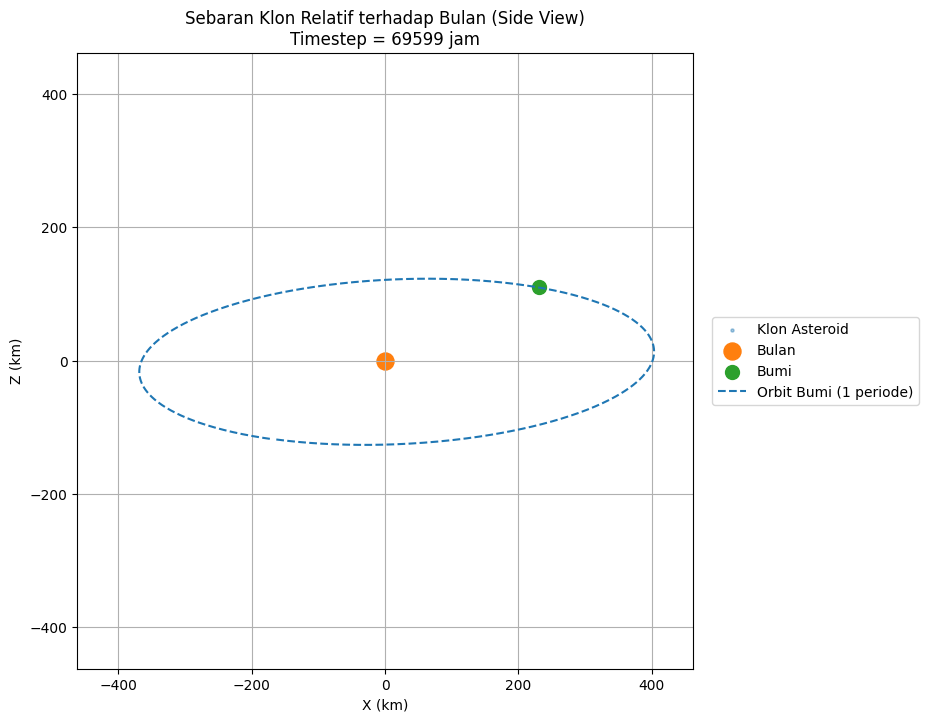

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# =========================
# Parameter
# =========================
timesteps = range(69400, 69600, 1)
moon_period = int(27.321661 * 24)
half_period = moon_period // 2

# =========================
# Radius orbit (untuk limit tetap)
# =========================
moon_distance = np.linalg.norm(moon_pos - earth_pos, axis=1)
orbit_radius = moon_distance.mean()
limit = orbit_radius * 1.2

# =========================
# Setup Figure
# =========================
fig, ax = plt.subplots(figsize=(8, 8))

scat_clone = ax.scatter([], [], s=5, alpha=0.4, label="Klon Asteroid")
scat_moon  = ax.scatter(0, 0, s=150, marker='o', label="Bulan")
scat_earth = ax.scatter([], [], s=100, marker='o', label="Bumi")

orbit_earth_line, = ax.plot([], [], linestyle='--',
                            linewidth=1.5,
                            label="Orbit Bumi (1 periode)")

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal')
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel("X (km)")
ax.set_ylabel("Z (km)")  # sekarang Z, bukan Y


# =========================
# Update Function (SIDE VIEW)
# =========================
def update(t_idx):

    clone_pos = data[t_idx]
    earth = earth_pos[t_idx]
    moon = moon_pos[t_idx]

    # Relatif terhadap Bulan
    rel_clone = clone_pos - moon
    rel_earth = earth - moon

    # SIDE VIEW → ambil X dan Z
    x = rel_clone[:, 0]
    z = rel_clone[:, 2]

    earth_x = rel_earth[0]
    earth_z = rel_earth[2]

    # Update klon
    scat_clone.set_offsets(np.c_[x, z])

    # Update Bumi
    scat_earth.set_offsets([earth_x, earth_z])

    # Orbit Bumi relatif Bulan
    start = max(0, t_idx - half_period)
    end   = min(len(earth_pos), t_idx + half_period)

    earth_segment = earth_pos[start:end] - moon_pos[start:end]

    orbit_earth_line.set_data(
        earth_segment[:, 0],
        earth_segment[:, 2]
    )

    ax.set_title(
        f"Sebaran Klon Relatif terhadap Bulan (Side View)\n"
        f"Timestep = {t_idx} jam"
    )

    return scat_clone, scat_earth, orbit_earth_line


# =========================
# Animasi
# =========================
ani = FuncAnimation(fig,
                    update,
                    frames=timesteps,
                    interval=50)

ani.save("orbit_moon_centered_sideview.gif",
         writer=PillowWriter(fps=5))

plt.show()

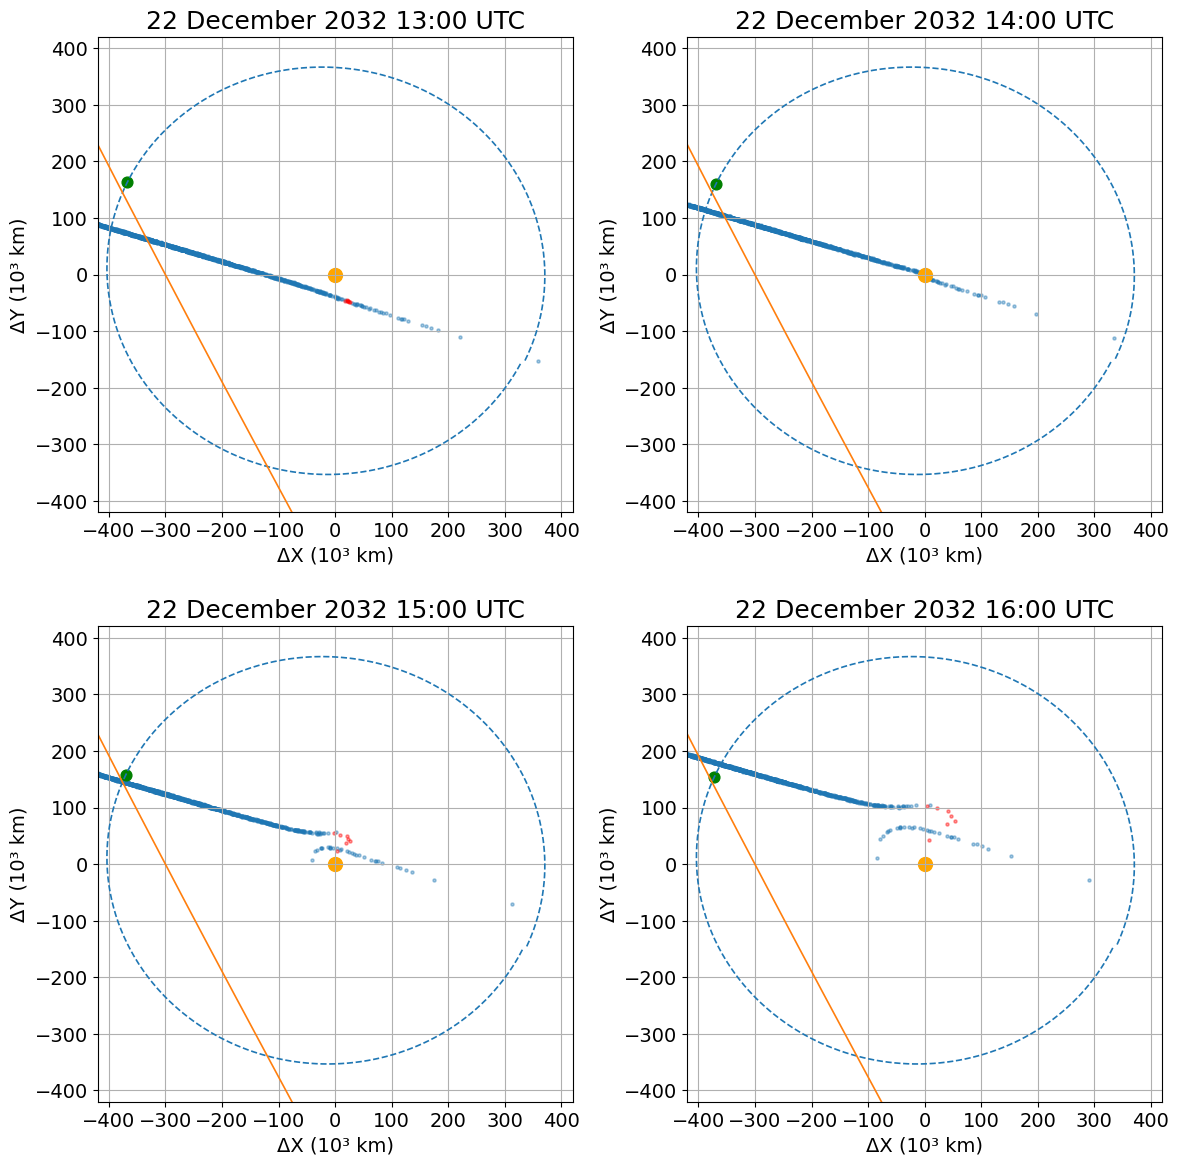

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime, timedelta
# samakan ukuran font
f_size=14
# samakan ukuran font
plt.rcParams.update({
    "font.size": f_size,
    "axes.titlesize": f_size+4,
    "axes.labelsize": f_size,
    "xtick.labelsize": f_size,
    "ytick.labelsize": f_size,
    "legend.fontsize": f_size
})
# =========================
# LOAD DATA TABRAKAN
# =========================
dist_min = np.load(r"D:\PENTING KUYLAH\output\3\dist.npy")

earth_dist = np.zeros(dist_min.shape[1])

for i in range(dist_min.shape[1]):
    earth_dist[i] = np.min(dist_min[:, i, 1])

AU_TO_KM = 149_597_870.7
earth_dist_km = earth_dist * AU_TO_KM
R_earth = 6371

impact_indices = np.where(earth_dist_km < R_earth)[0]

# =========================
# PARAMETER
# =========================
t_list = [ 69445, 69446, 69447,69448]
clone_index = 0

t0 = datetime(2025, 1, 20, 0, 0)

fixed_min = -420
fixed_max =  420
tick_interval = 100

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, t_idx in zip(axes, t_list):

    clone_pos = data[t_idx]
    earth = earth_pos[t_idx]
    moon = moon_pos[t_idx]

    rel_clone = clone_pos - earth
    rel_moon = moon - earth

    # Pisahkan klon
    all_indices = np.arange(rel_clone.shape[0])
    normal_indices = np.setdiff1d(all_indices, impact_indices)

    clone_normal = rel_clone[normal_indices]
    clone_impact = rel_clone[impact_indices]

    # =========================
    # WAKTU
    # =========================
    current_time = t0 + timedelta(hours=int(t_idx))
    time_str = current_time.strftime("%d %B %Y %H:%M UTC")

    # =========================
    # SCATTER KLON (STYLE SAMA)
    # =========================
    if len(clone_normal) > 0:
        ax.scatter(clone_normal[:, 0],
                   clone_normal[:, 1],
                   s=5,
                   alpha=0.4
                   )

    if len(clone_impact) > 0:
        ax.scatter(clone_impact[:, 0],
                   clone_impact[:, 1],
                   s=5,          # ukuran sama
                   alpha=0.4,    # alpha sama
                   color='red')

    # Earth (oranye)
    ax.scatter(0, 0, s=100, color='orange')

    # Moon (hijau)
    ax.scatter(rel_moon[0],
               rel_moon[1],
               s=60,
               color='green')

    # =========================
    # ORBIT BULAN
    # =========================
    moon_period = int(27.321661 * 24)
    half_period = moon_period // 2

    start = max(0, t_idx - half_period)
    end   = min(len(moon_pos), t_idx + half_period)

    moon_segment = moon_pos[start:end] - earth_pos[start:end]

    ax.plot(moon_segment[:, 0],
            moon_segment[:, 1],
            linestyle='--',
            linewidth=1.2)

    # Orbit 1 klon
    clone_orbit_rel = data[:, clone_index, :] - earth_pos
    ax.plot(clone_orbit_rel[:, 0],
            clone_orbit_rel[:, 1],
            linewidth=1.2)

    # =========================
    # LIMIT & STYLE (SAMA PERSIS)
    # =========================
    ax.set_xlim(fixed_min, fixed_max)
    ax.set_ylim(fixed_min, fixed_max)

    ax.xaxis.set_major_locator(MultipleLocator(tick_interval))
    ax.yaxis.set_major_locator(MultipleLocator(tick_interval))

    ax.set_xlabel("ΔX (10³ km)")
    ax.set_ylabel("ΔY (10³ km)")
    ax.set_aspect('equal', adjustable='box')

    ax.set_title(time_str)

    ax.grid(True)

plt.tight_layout()
plt.savefig("perubahan_close_approach_3.png", dpi=600, bbox_inches="tight")
plt.show()

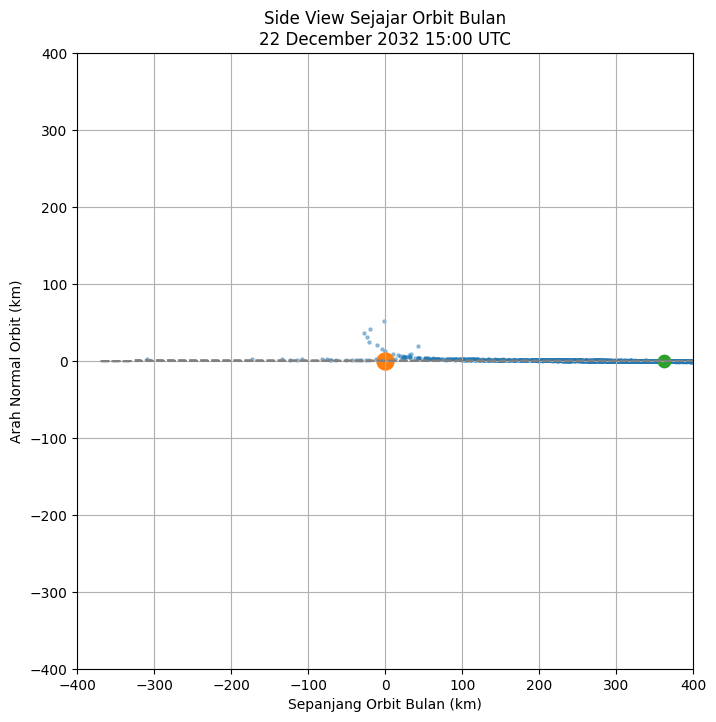

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

t_idx = 69447

# =========================
# WAKTU
# =========================
t0 = datetime(2025, 1, 20, 0, 0, 0)
current_time = t0 + timedelta(hours=t_idx)
time_str = current_time.strftime("%d %B %Y %H:%M UTC")

clone_pos = data[t_idx]
earth = earth_pos[t_idx]
moon = moon_pos[t_idx]

# =========================
# RELATIF TERHADAP BUMI
# =========================
rel_clone = clone_pos - earth
rel_moon  = moon - earth

# =========================
# AMBIL SEGMENT ORBIT BULAN
# =========================
moon_period = int(27.321661 * 24)
half_period = moon_period // 2

start = max(0, t_idx - half_period)
end   = min(len(moon_pos), t_idx + half_period)

moon_segment = moon_pos[start:end] - earth_pos[start:end]

# =========================
# PCA → BIDANG ORBIT
# =========================
cov = np.cov(moon_segment.T)
eigvals, eigvecs = np.linalg.eigh(cov)

# Urutkan eigenvalue terbesar → terkecil
order = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, order]

e1 = eigvecs[:, 0]   # arah utama orbit
e2 = eigvecs[:, 2]   # normal bidang orbit
e3 = np.cross(e2, e1)

# Normalisasi
e1 /= np.linalg.norm(e1)
e2 /= np.linalg.norm(e2)
e3 /= np.linalg.norm(e3)

# =========================
# PROYEKSI KE KOORDINAT BARU
# =========================
x_clone = rel_clone @ e1
y_clone = rel_clone @ e2   # ini arah normal (harus kecil)

x_moon = rel_moon @ e1
y_moon = rel_moon @ e2

x_orbit = moon_segment @ e1
y_orbit = moon_segment @ e2

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,8))

plt.scatter(x_clone, y_clone, s=5, alpha=0.4)
plt.scatter(0, 0, s=150)          # Earth
plt.scatter(x_moon, y_moon, s=80) # Moon

plt.plot(x_orbit, y_orbit,
         linestyle='--',
         color='grey',
         linewidth=1.5)

plt.xlim(-400, 400)
plt.ylim(-400, 400)

plt.xlabel("Sepanjang Orbit Bulan (km)")
plt.ylabel("Arah Normal Orbit (km)")
plt.title(f"Side View Sejajar Orbit Bulan\n{time_str}")

plt.gca().set_aspect('equal')
plt.grid(True)

plt.show()